<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-ev-charging-stations-ml-100?scriptVersionId=260006281" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-ev-charging-stations/ev_models_2025.csv
/kaggle/input/global-ev-charging-stations/world_summary_2025.csv
/kaggle/input/global-ev-charging-stations/country_summary_2025.csv
/kaggle/input/global-ev-charging-stations/charging_stations_2025_world.csv


## Title: Global EV Charging Stations

## Description:
This dataset provides detailed insights into the availability, growth, and distribution of electric vehicle (EV) charging stations worldwide. It includes information on station locations, charging types (fast, standard, ultra-fast), accessibility, and regional adoption trends. Such data helps in analyzing infrastructure readiness, identifying gaps in EV adoption, supporting urban planning, and driving sustainable transportation policies.

## Import dataset

In [2]:
ev_models = pd.read_csv("/kaggle/input/global-ev-charging-stations/ev_models_2025.csv")
world_summary = pd.read_csv("/kaggle/input/global-ev-charging-stations/world_summary_2025.csv")
country_summary = pd.read_csv("/kaggle/input/global-ev-charging-stations/country_summary_2025.csv")
charging_stations = pd.read_csv("/kaggle/input/global-ev-charging-stations/charging_stations_2025_world.csv")

In [3]:
print("EV Models shape:", ev_models.shape)
print("World Summary shape:", world_summary.shape)
print("Country Summary shape:", country_summary.shape)
print("Charging Stations shape:", charging_stations.shape)

EV Models shape: (63, 7)
World Summary shape: (122, 4)
Country Summary shape: (122, 2)
Charging Stations shape: (242417, 11)


In [4]:
print("\nEV Models sample:")
display(ev_models.head())



EV Models sample:


,make,model,market_regions,powertrain,first_year,body_style,origin_country
0,Tesla,Model S,Global (US/EU/UK/ME),BEV,2012,Sedan,US
1,Tesla,Model 3,Global (US/EU/UK/ME/CN),BEV,2017,Sedan,US
2,Tesla,Model X,Global (US/EU/UK/ME),BEV,2015,SUV,US
3,Tesla,Model Y,Global (US/EU/UK/ME/CN),BEV,2020,SUV,US
4,Tesla,Cybertruck,US (limited),BEV,2023,Pickup,US


In [5]:
print("\nWorld Summary sample:")
display(world_summary.head())


World Summary sample:


,country_code,country,count,max_power_kw_max
0,US,United States,83821,600.0
1,GB,United Kingdom,27437,560.0
2,DE,Germany,24465,400.0
3,CA,Canada,18203,400.0
4,ES,Spain,17864,1000.0


In [6]:
print("\nCountry Summary sample:")
display(country_summary.head())


Country Summary sample:


,country_code,stations
0,US,82138
1,GB,26825
2,DE,23373
3,ES,17825
4,CA,16490


In [7]:
print("\nCharging Stations sample:")
display(charging_stations.head())


Charging Stations sample:


,id,name,city,country_code,state_province,latitude,longitude,ports,power_kw,power_class,is_fast_dc
0,307660,Av. de Tarragona,Andorra,AD,NaN,42.505254,1.528861,10,300.0,DC_ULTRA_(>=150kW),True
1,301207,Parquing Costa Rodona,Encamp,AD,NaN,42.537213,1.727014,10,22.0,AC_HIGH_(22-49kW),False
2,301206,Hotel Naudi,NaN,AD,NaN,42.576811,1.666061,1,11.0,AC_L2_(7.5-21kW),False
3,301205,Hotel Piolets Soldeu Centre,NaN,AD,NaN,42.576466,1.667317,1,22.0,AC_HIGH_(22-49kW),False
4,301204,Hotel Serras,NaN,AD,NaN,42.579458,1.659215,3,11.0,AC_L2_(7.5-21kW),False


## Data Visualizations

In [8]:
files = {
    "ev_models": "/kaggle/input/global-ev-charging-stations/ev_models_2025.csv",
    "world_summary": "/kaggle/input/global-ev-charging-stations/world_summary_2025.csv",
    "country_summary": "/kaggle/input/global-ev-charging-stations/country_summary_2025.csv",
    "charging_stations": "/kaggle/input/global-ev-charging-stations/charging_stations_2025_world.csv",
}

In [9]:
for name, path in files.items():
    df = pd.read_csv(path, nrows=5)  # read small sample
    print(f"\n{name} columns:")
    print(df.columns.tolist())


ev_models columns:
['make', 'model', 'market_regions', 'powertrain', 'first_year', 'body_style', 'origin_country']

world_summary columns:
['country_code', 'country', 'count', 'max_power_kw_max']

country_summary columns:
['country_code', 'stations']

charging_stations columns:
['id', 'name', 'city', 'country_code', 'state_province', 'latitude', 'longitude', 'ports', 'power_kw', 'power_class', 'is_fast_dc']


## EV MODELS

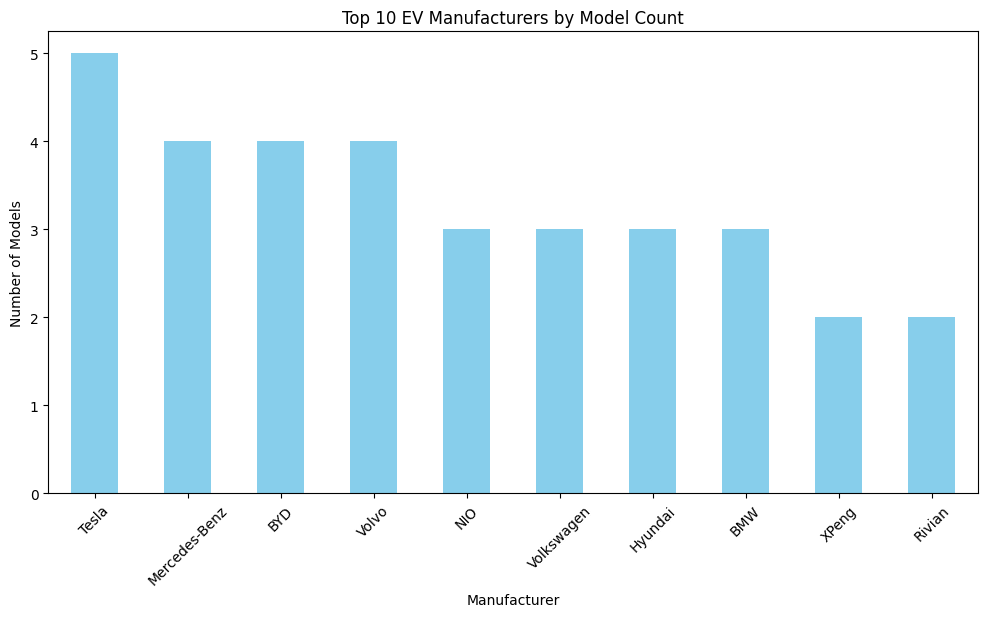

In [10]:
plt.figure(figsize=(12,6))
ev_models["make"].value_counts().head(10).plot(kind="bar", color="skyblue")
plt.title("Top 10 EV Manufacturers by Model Count")
plt.ylabel("Number of Models")
plt.xlabel("Manufacturer")
plt.xticks(rotation=45)
plt.show()

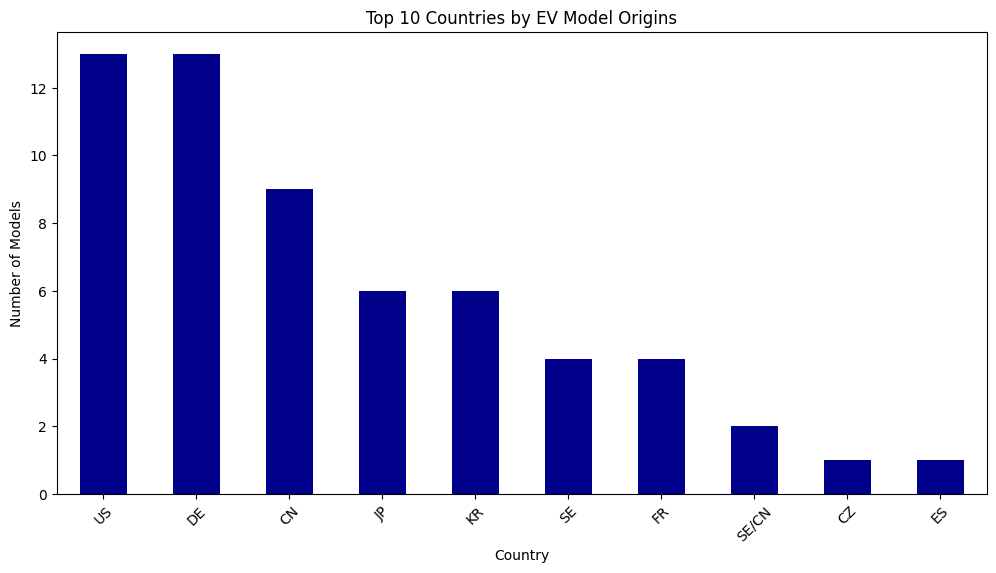

In [11]:
plt.figure(figsize=(12,6))
ev_models["origin_country"].value_counts().head(10).plot(kind="bar", color="darkblue")
plt.title("Top 10 Countries by EV Model Origins")
plt.ylabel("Number of Models")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.show()

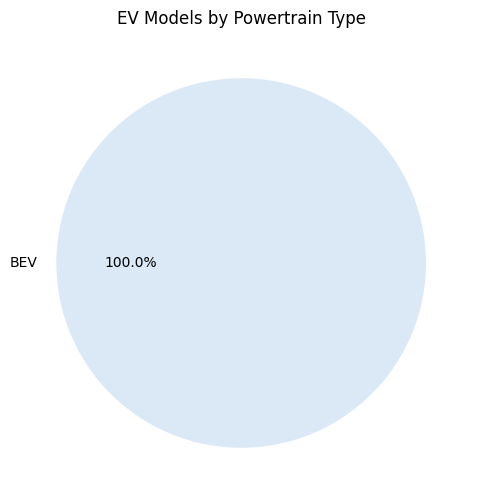

In [12]:
plt.figure(figsize=(8,6))
ev_models["powertrain"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=sns.color_palette("Blues"))
plt.title("EV Models by Powertrain Type")
plt.ylabel("")
plt.show()

## world_summary_2025.csv

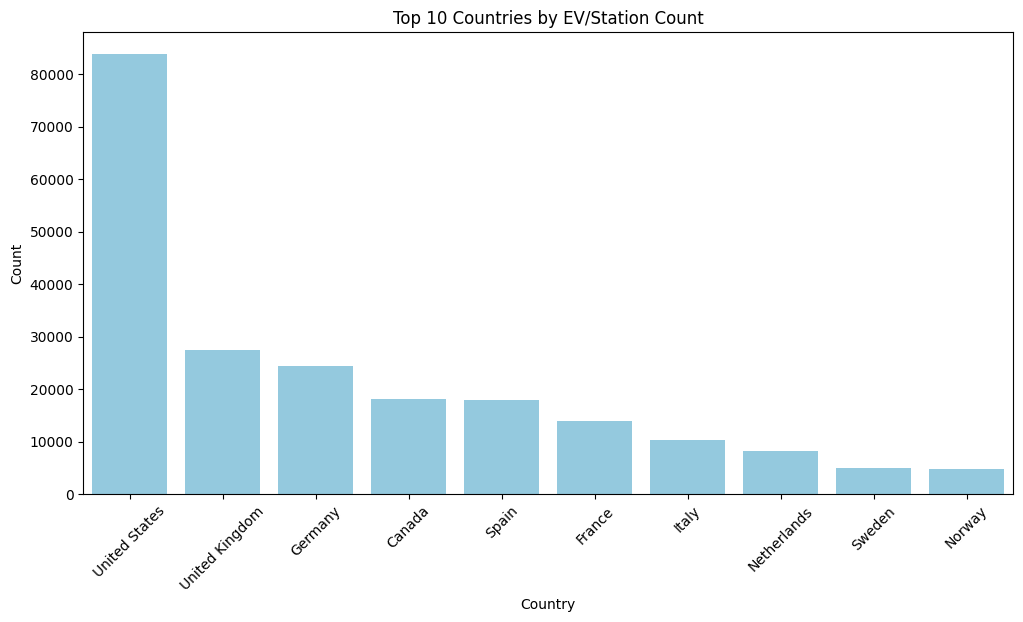

In [13]:
top_world = world_summary.sort_values("count", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_world, x="country", y="count", color="skyblue")
plt.title("Top 10 Countries by EV/Station Count")
plt.ylabel("Count")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.show()


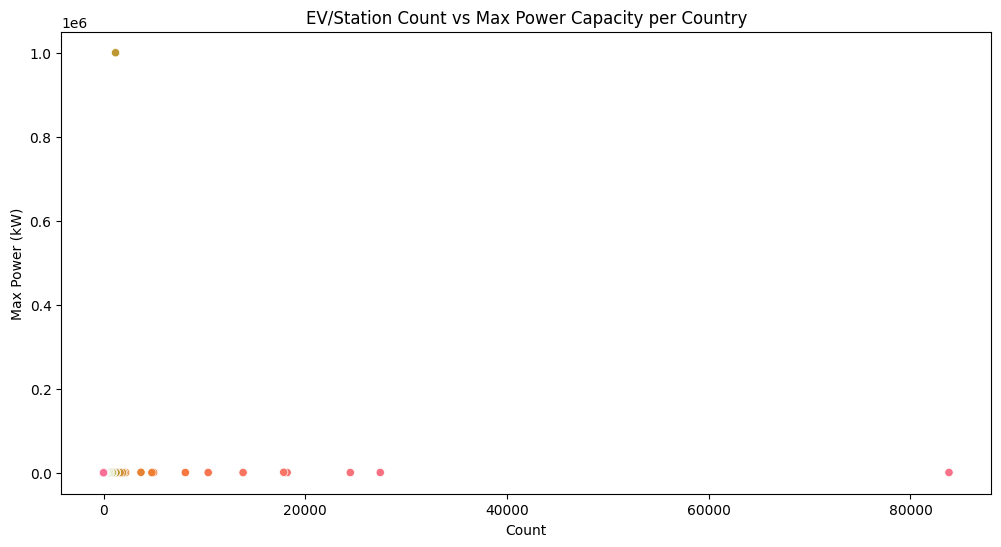

In [14]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=world_summary, x="count", y="max_power_kw_max", hue="country", legend=False)
plt.title("EV/Station Count vs Max Power Capacity per Country")
plt.xlabel("Count")
plt.ylabel("Max Power (kW)")
plt.show()

## country_summary_2025.csv

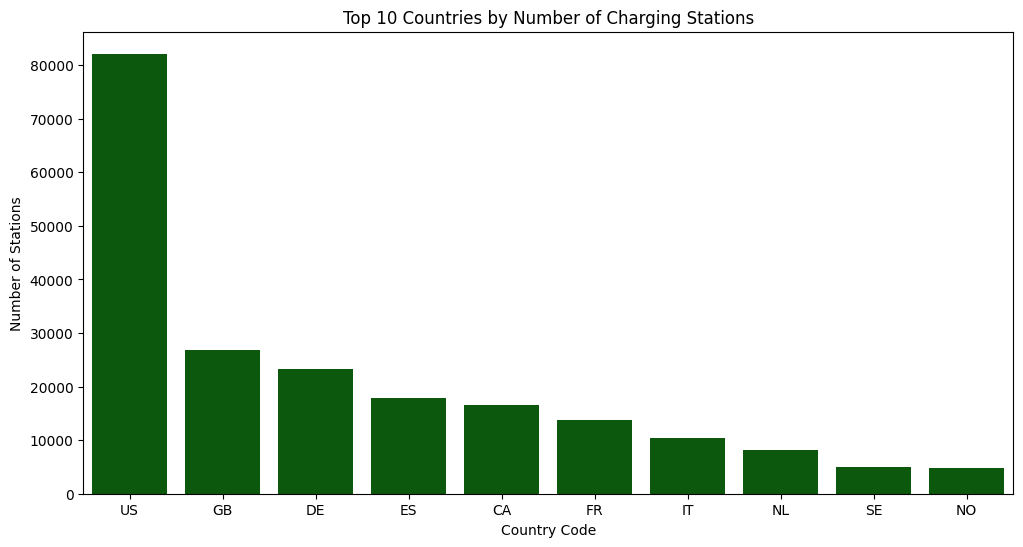

In [15]:
top_countries = country_summary.sort_values("stations", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_countries, x="country_code", y="stations", color="darkgreen")
plt.title("Top 10 Countries by Number of Charging Stations")
plt.ylabel("Number of Stations")
plt.xlabel("Country Code")
plt.show()

## charging_stations_2025_world.csv

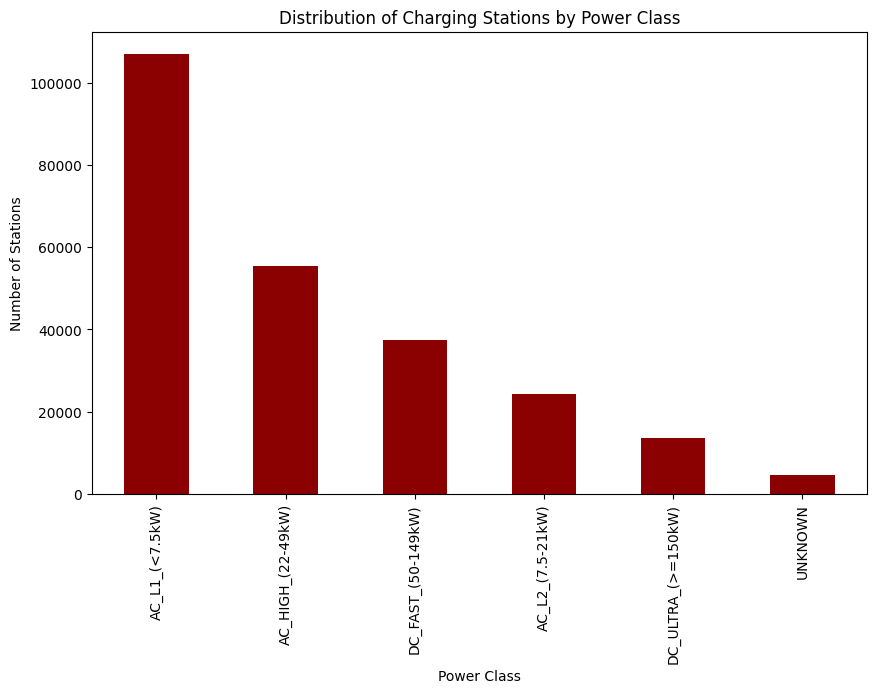

In [16]:
plt.figure(figsize=(10,6))
charging_stations["power_class"].value_counts().plot(kind="bar", color="darkred")
plt.title("Distribution of Charging Stations by Power Class")
plt.ylabel("Number of Stations")
plt.xlabel("Power Class")
plt.show()

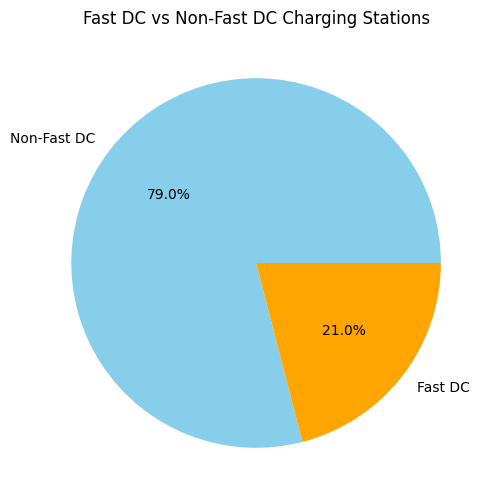

In [17]:
plt.figure(figsize=(8,6))
charging_stations["is_fast_dc"].value_counts().plot(kind="pie", autopct="%1.1f%%", labels=["Non-Fast DC", "Fast DC"], colors=["skyblue","orange"])
plt.title("Fast DC vs Non-Fast DC Charging Stations")
plt.ylabel("")
plt.show()

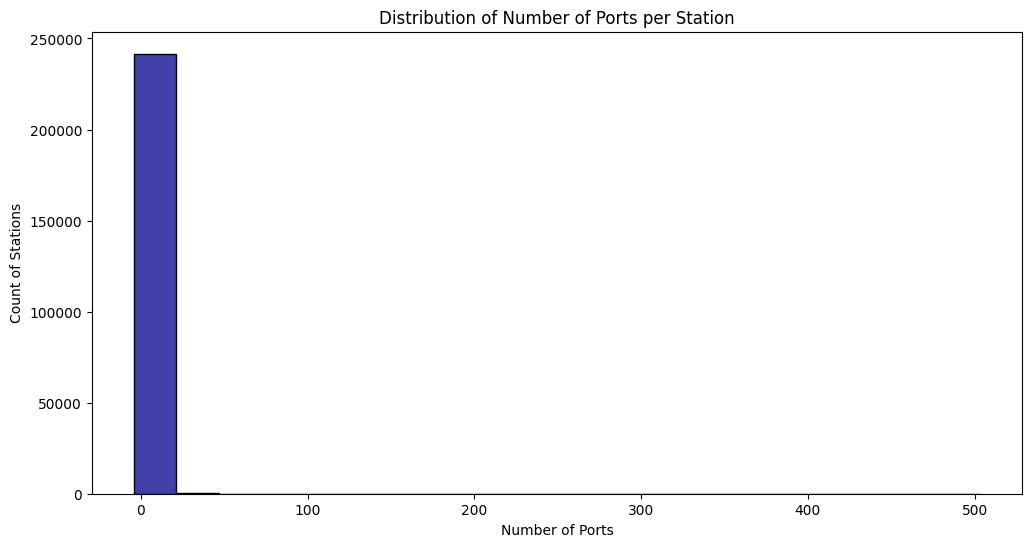

In [18]:
plt.figure(figsize=(12,6))
sns.histplot(charging_stations["ports"], bins=20, color="darkblue")
plt.title("Distribution of Number of Ports per Station")
plt.xlabel("Number of Ports")
plt.ylabel("Count of Stations")
plt.show()

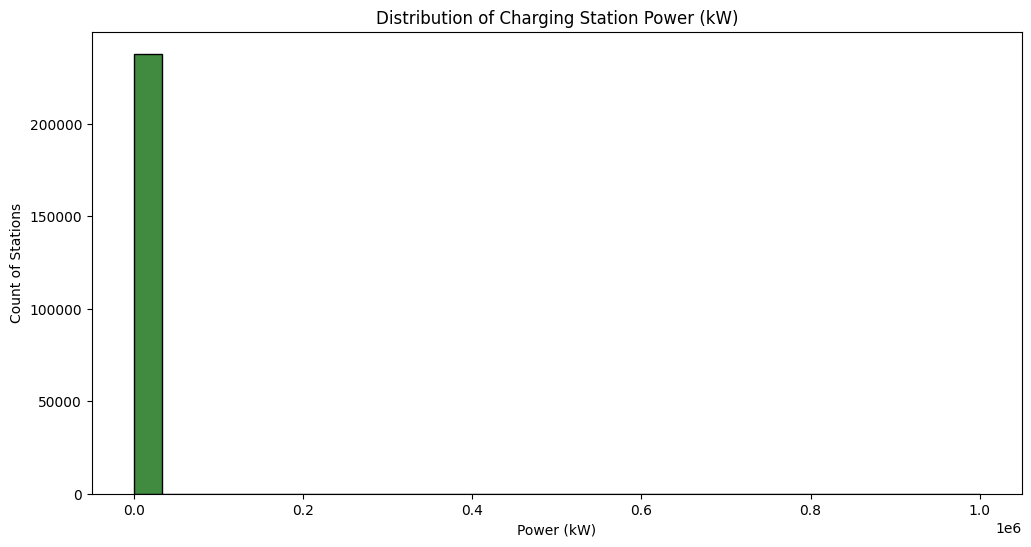

In [19]:
plt.figure(figsize=(12,6))
sns.histplot(charging_stations["power_kw"], bins=30, color="darkgreen")
plt.title("Distribution of Charging Station Power (kW)")
plt.xlabel("Power (kW)")
plt.ylabel("Count of Stations")
plt.show()

## ML Algorithms 

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb

In [21]:
# Select features & target
X = charging_stations[["ports", "power_kw", "power_class"]]
y = charging_stations["is_fast_dc"]

In [22]:
# Encode categorical feature (power_class)
le = LabelEncoder()
X["power_class"] = le.fit_transform(X["power_class"].astype(str))


In [23]:
# Handle missing values
imputer = SimpleImputer(strategy="mean")  # for numeric columns
X[["ports", "power_kw"]] = imputer.fit_transform(X[["ports", "power_kw"]])

In [24]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(eval_metric="mlogloss", use_label_encoder=False),
    "LightGBM": lgb.LGBMClassifier()
}


In [26]:
# Train & evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    results.append((name, round(acc, 2)))

[LightGBM] [Info] Number of positive: 40742, number of negative: 153191
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002345 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 187
[LightGBM] [Info] Number of data points in the train set: 193933, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.210083 -> initscore=-1.324426
[LightGBM] [Info] Start training from score -1.324426
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [27]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy (%)"]).sort_values(by="Accuracy (%)", ascending=False)
print(results_df)

                 Model  Accuracy (%)
0  Logistic Regression        100.00
1        Decision Tree        100.00
2        Random Forest        100.00
3    Gradient Boosting        100.00
4                  KNN        100.00
5                  SVM        100.00
7              XGBoost        100.00
8             LightGBM        100.00
6          Naive Bayes         98.02


## Thank you...pls upvote!!!!
